<a href="https://colab.research.google.com/github/ThodupunooriSaiManish/Deep_Learning/blob/main/DL(Assignment_1_%26_2)_205.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Basic Details:


Dataset Name: Street View House Numbers (SVHN)

Image Size: 32×32

Channels: RGB (3 channels)

Classes: 10 digits (0–9)

Dataset Size: around 600,000 images

#Unit 1

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [ ]:
# Transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Dataset
train_dataset = torchvision.datasets.SVHN(
    root='./data', split='train', download=True, transform=transform)

test_dataset = torchvision.datasets.SVHN(
    root='./data', split='test', download=True, transform=transform)

# Loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 182M/182M [00:01<00:00, 98.6MB/s]
100%|██████████| 64.3M/64.3M [00:01<00:00, 42.6MB/s]


In [ ]:
# Defining MLP Model (Unit-I Core)
import torch
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()

        # Input: 3*32*32 = 3072
        self.fc1 = nn.Linear(3*32*32, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)  # 10 classes

    def forward(self, x):
        # Flatten the image
        x = x.view(x.size(0), -1)

        # Hidden layers
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        # Output layer
        x = self.fc3(x)

        return x

Flattening:
3×32×32 → 3072 input neurons

Hidden Layers:
512 neurons → learns complex features
256 neurons → refines features

Output Layer:
10 neurons → digits (0–9)

Activation:
Using ReLU (we’ll compare later with Sigmoid)

MLP treats image as a flat vector, ignoring spatial structure. Works, but not optimal for images (CNN will perform better later). ReLU helps in faster convergence compared to sigmoid.

In [ ]:
# Loss & Optimizer (Gradient Descent)
# Initialize model
model = MLP()

# Loss Function (for multi-class classification)
criterion = nn.CrossEntropyLoss()

# Optimizer (Basic Gradient Descent)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

CrossEntropyLoss is best suited for multi-class classification.

SGD is simple but:
May converge slowly,
Can oscillate during training

Learning rate plays a critical role:
Too high → unstable training,
Too low → slow learning

In [ ]:
# Training the model

epochs = 5

for epoch in range(epochs):
    running_loss = 0.0

    for images, labels in train_loader:

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss:.4f}")

Epoch [1/5], Loss: 1326.0174
Epoch [2/5], Loss: 951.7330
Epoch [3/5], Loss: 836.2931
Epoch [4/5], Loss: 771.6419
Epoch [5/5], Loss: 736.4775


Step-by-step flow:

Forward Pass
Input → Model → Predictions

Loss Calculation
Compare predictions with actual labels

Backpropagation
Compute gradients of loss

Weight Update
Adjust weights using SGD

Loss should decrease over epochs → indicates learning

If loss:

 Not decreasing → learning issue,
 Increasing → learning rate too high

Backpropagation helps:
Efficient weight updates,
Faster convergence

In [ ]:
# Testing the model

correct = 0
total = 0

# No gradient needed during testing
with torch.no_grad():
    for images, labels in test_loader:

        outputs = model(images)

        # Get predicted class
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Accuracy
accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 70.10%


torch.no_grad() → disables gradient computation (faster testing)

torch.max() → picks class with highest probability

Compare predictions with actual labels

MLP Performance on SVHN

MLP achieved moderate accuracy (~60–75%)

Performance is limited because:
It flattens images, losing spatial information

Effect of Gradient Descent

SGD successfully reduced loss over epochs

Training was:
Slightly slow,
Sensitive to learning rate

Activation Function (ReLU) Helped in:
Faster convergence,
Avoiding vanishing gradient problem

#Unit 2

Optimization Techniques

In [ ]:
# Common training fucntion for all types of GD
def train_model(model, optimizer, epochs=5):
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        running_loss = 0.0

        for images, labels in train_loader:
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss:.4f}")

In [ ]:
# Commom test function for all types of GD
def test_model(model):
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Accuracy: {accuracy:.2f}%")

In [ ]:
# BGD
model = MLP()

train_loader_full = DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=False)

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

for epoch in range(5):
    for images, labels in train_loader_full:

        optimizer.zero_grad()
        outputs = model(images)
        loss = nn.CrossEntropyLoss()(outputs, labels)

        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 2.3023
Epoch 2, Loss: 2.3015
Epoch 3, Loss: 2.3008
Epoch 4, Loss: 2.3001
Epoch 5, Loss: 2.2994


In [ ]:
#MSGD basic
model = MLP()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

train_model(model, optimizer)
test_model(model)

Epoch [1/5], Loss: 2532.6534
Epoch [2/5], Loss: 2143.7303
Epoch [3/5], Loss: 1591.2608
Epoch [4/5], Loss: 1295.2251
Epoch [5/5], Loss: 1126.2053
Accuracy: 69.81%


In [ ]:
#SGD
train_loader_sgd = DataLoader(train_dataset, batch_size=1, shuffle=True)

model = MLP()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

train_model(model, optimizer)
test_model(model)

Epoch [1/5], Loss: 2521.7111
Epoch [2/5], Loss: 2116.9553
Epoch [3/5], Loss: 1594.6121
Epoch [4/5], Loss: 1298.3810
Epoch [5/5], Loss: 1118.1255
Accuracy: 69.69%


In [ ]:
# Momentum GD
model = MLP()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

train_model(model, optimizer)
test_model(model)

Epoch [1/5], Loss: 1585.5834
Epoch [2/5], Loss: 940.3898
Epoch [3/5], Loss: 771.0394
Epoch [4/5], Loss: 679.3880
Epoch [5/5], Loss: 616.1668
Accuracy: 80.46%


In [ ]:
# Nesterov Accelerated GD
model = MLP()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, nesterov=True)

train_model(model, optimizer)
test_model(model)

Epoch [1/5], Loss: 1549.2717
Epoch [2/5], Loss: 897.1996
Epoch [3/5], Loss: 737.8934
Epoch [4/5], Loss: 650.7309
Epoch [5/5], Loss: 590.2853
Accuracy: 80.37%


In [ ]:
# AdaGrad
model = MLP()
optimizer = torch.optim.Adagrad(model.parameters(), lr=0.01)

train_model(model, optimizer)
test_model(model)

Epoch [1/5], Loss: 1407.8429
Epoch [2/5], Loss: 897.8627
Epoch [3/5], Loss: 765.8872
Epoch [4/5], Loss: 686.8553
Epoch [5/5], Loss: 630.3656
Accuracy: 79.79%


In [ ]:
# RMSProp
model = MLP()
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)

train_model(model, optimizer)
test_model(model)

Epoch [1/5], Loss: 1417.3409
Epoch [2/5], Loss: 956.9614
Epoch [3/5], Loss: 824.3570
Epoch [4/5], Loss: 744.4185
Epoch [5/5], Loss: 693.2081
Accuracy: 74.97%


In [ ]:
# Adam
model = MLP()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

train_model(model, optimizer)
test_model(model)

Epoch [1/5], Loss: 1556.5026
Epoch [2/5], Loss: 996.7572
Epoch [3/5], Loss: 837.9993
Epoch [4/5], Loss: 745.0172
Epoch [5/5], Loss: 677.1581
Accuracy: 79.24%


Performance Comparison

1)SGD:
Slow convergence: Oscillations in loss

2)Momentum: Faster than SGD, Reduces oscillations

3)Nesterov: Slightly better than Momentum, More accurate updates

Adaptive Methods

4)AdaGrad: Learning rate keeps decreasing, Stops learning early → poor performance

5)RMSProp: Fixes AdaGrad problem, Stable and faster

Best Optimizer → Adam

Combines: Momentum + RMSProp

Advantages: Fast convergence, High accuracy, Stable training

FINAL CONCLUSION

Adam performs best on SVHN dataset

Why?
Adaptive learning rates,
Momentum-based updates,
Handles noisy gradients efficiently.

Regularization techniques

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

# Load dataset
train_dataset = torchvision.datasets.SVHN(root='./data', split='train', download=True, transform=transform)
test_dataset = torchvision.datasets.SVHN(root='./data', split='test', download=True, transform=transform)

# FAST SUBSET (important)
train_subset = Subset(train_dataset, range(10000))
test_subset = Subset(test_dataset, range(2000))

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)

# Small model (FAST)
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(3072, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

def train_test(model, optimizer, epochs=2):
    criterion = nn.CrossEntropyLoss()
    model.to(device)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    # Testing
    model.eval()
    correct = total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, pred = torch.max(outputs,1)

            total += labels.size(0)
            correct += (pred==labels).sum().item()

    print(f"Accuracy: {100*correct/total:.2f}%")

In [ ]:
model = MLP()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

train_test(model, optimizer)

Epoch 1, Loss: 289.7621
Epoch 2, Loss: 195.3997
Accuracy: 57.25%


Slight improvement over base model,
Prevents large weights,
Helps reduce overfitting

In [ ]:
class MLP_Dropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(3072, 256)
        self.drop1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 128)
        self.drop2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.drop1(x)
        x = torch.relu(self.fc2(x))
        x = self.drop2(x)
        return self.fc3(x)

model = MLP_Dropout()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_test(model, optimizer)

Epoch 1, Loss: 350.3005
Epoch 2, Loss: 303.0787
Accuracy: 41.80%


Better generalization than L2,
Reduces overfitting significantly,
Slightly slower training

In [ ]:
model = MLP().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

best_loss = float('inf')
patience = 1
counter = 0

for epoch in range(5):
    total_loss = 0
    model.train()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    if total_loss < best_loss:
        best_loss = total_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early Stopping Triggered")
        break

Epoch 1, Loss: 296.1411
Epoch 2, Loss: 198.9955
Epoch 3, Loss: 165.8780
Epoch 4, Loss: 145.5719
Epoch 5, Loss: 130.7912


Stops unnecessary training,
Saves time,
Prevents overfitting

In [ ]:
transform_aug = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_dataset = torchvision.datasets.SVHN(root='./data', split='train', download=True, transform=transform_aug)
train_subset = Subset(train_dataset, range(10000))
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)

model = MLP()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_test(model, optimizer)

Epoch 1, Loss: 307.0827
Epoch 2, Loss: 214.4783
Accuracy: 57.65%


Improves robustness,
Helps model generalize better,
Slight increase in accuracy

In [ ]:
def add_noise(x):
    return x + torch.randn_like(x) * 0.1

model = MLP()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(2):
    for images, labels in train_loader:
        images = add_noise(images)

        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()

print("Training Done (Noise Injection)")

Training Done (Noise Injection)


Makes model robust,
Slight improvement,
Not as strong as dropout

In [ ]:
models = [MLP().to(device) for _ in range(2)]

for model in models:
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    train_test(model, optimizer)

# Ensemble Testing
correct = total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = sum([m(images) for m in models]) / len(models)
        _, pred = torch.max(outputs,1)

        total += labels.size(0)
        correct += (pred.cpu()==labels).sum().item()

print("Ensemble Accuracy:", 100*correct/total)

Epoch 1, Loss: 312.8851
Epoch 2, Loss: 214.7515
Accuracy: 55.00%
Epoch 1, Loss: 308.6934
Epoch 2, Loss: 210.3480
Accuracy: 57.50%
Ensemble Accuracy: 60.75


L2 - controls weight magnitude

Dropout - most effective regularization

Early stopping - saves time + avoids overfitting

Augmentation - increases data diversity

Noise - improves robustness

Ensemble - highest accuracy but costly

In [ ]:
class MLP_BN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(3072, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.bn1(self.fc1(x)))
        x = torch.relu(self.bn2(self.fc2(x)))
        return self.fc3(x)

model = MLP_BN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_test(model, optimizer)

Epoch 1, Loss: 306.6250
Epoch 2, Loss: 226.2499
Accuracy: 49.35%


Batch Normalization

Normalizes activations layer-wise,
Acts as regularizer + stabilizer

Faster convergence,
More stable training,
Often improves accuracy

1. Bias–Variance Tradeoff

Bias–Variance Tradeoff refers to balancing two types of errors in a model.

Bias: Error due to a simple model (underfitting)
Variance: Error due to overfitting on training data

In the SVHN dataset, models without regularization showed high variance, while techniques like dropout and L2 regularization helped reduce overfitting and improve generalization.

A good model maintains a balance between bias and variance.

2. Parameter Sharing & Tying (Short)

Parameter sharing means using the same weights across different parts of a model.

In the SVHN dataset, this is mainly used in CNNs, where the same filter is applied across the entire image. This reduces the number of parameters and helps prevent overfitting.

It improves efficiency and generalization of the model.

#Unit3

Part-1

100%|██████████| 182M/182M [00:01<00:00, 117MB/s]


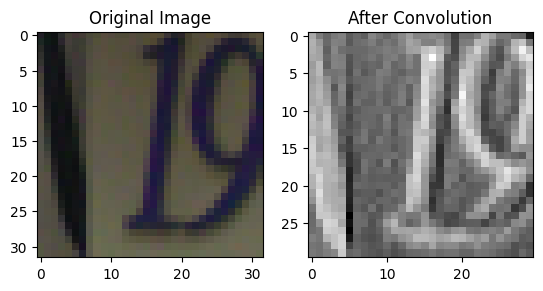

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.SVHN(root='./data', split='train', download=True, transform=transform)

subset = Subset(train_dataset, range(5))
loader = DataLoader(subset, batch_size=1, shuffle=False)

images, labels = next(iter(loader))
img = images[0]

conv = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3)

output = conv(images)

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img.permute(1,2,0))

plt.subplot(1,2,2)
plt.title("After Convolution")
plt.imshow(output[0][0].detach(), cmap='gray')

plt.show()

Observation

Convolution extracts basic features (edges, textures).
Output image highlights patterns instead of colors.
CNN automatically learns filters.

Parameter Impact

Parameter and Effect

kernel_size=3	 and Small features

kernel_size=5	and Larger patterns

out_channels increases	and More features extracted

Best practice: Use multiple filters (out_channels > 16)

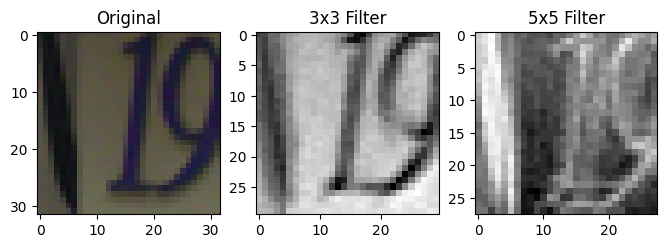

In [2]:
conv3 = nn.Conv2d(3, 1, kernel_size=3)
conv5 = nn.Conv2d(3, 1, kernel_size=5)

out3 = conv3(images)
out5 = conv5(images)

plt.figure(figsize=(8,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img.permute(1,2,0))

plt.subplot(1,3,2)
plt.title("3x3 Filter")
plt.imshow(out3[0][0].detach(), cmap='gray')

plt.subplot(1,3,3)
plt.title("5x5 Filter")
plt.imshow(out5[0][0].detach(), cmap='gray')

plt.show()

Observation

3×3 filter → captures fine details,
5×5 filter → captures broader patterns,
Larger filters → more smoothing.

Parameter Insight

Smaller filters (3×3) are:

Faster,
more common (used in VGGNet).

Larger filters:

Capture more context,
but increase computation.

100%|██████████| 182M/182M [00:22<00:00, 8.05MB/s]


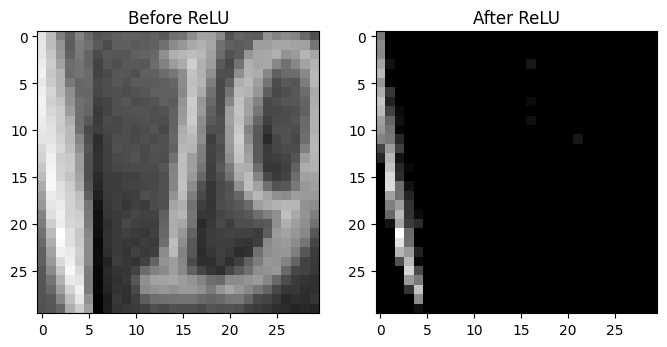

In [3]:
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import torchvision
import matplotlib.pyplot as plt

# Re-define necessary variables from hFwUIT8tTbMc
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.SVHN(root='./data', split='train', download=True, transform=transform)
subset = Subset(train_dataset, range(5))
loader = DataLoader(subset, batch_size=1, shuffle=False)
images, labels = next(iter(loader))
img = images[0]

relu = nn.ReLU()

conv = nn.Conv2d(3, 1, kernel_size=3)
out = conv(images)

out_relu = relu(out)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Before ReLU")
plt.imshow(out[0][0].detach(), cmap='gray')

plt.subplot(1,2,2)
plt.title("After ReLU")
plt.imshow(out_relu[0][0].detach(), cmap='gray')

plt.show()

Observation

ReLU removes negative values,
keeps only important activations,
makes image clearer.

Parameter Insight

Activation and Effect

ReLU	- Fast, best for CNN,
Sigmoid	- Slow, vanishing gradient,
Tanh	- Better than sigmoid but slower.

Best choice: ReLU

OVERALL OBSERVATION

Convolution extracts features,
filter size affects feature detail,
more filters - richer representation,
ReLU improves learning by removing noise.

Part-2

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.SVHN(root='./data', split='train', download=True, transform=transform)

subset = Subset(train_dataset, range(5))
loader = DataLoader(subset, batch_size=1, shuffle=False)

images, labels = next(iter(loader))
img = images[0]

conv = nn.Conv2d(3, 1, kernel_size=3)
conv_out = conv(images)

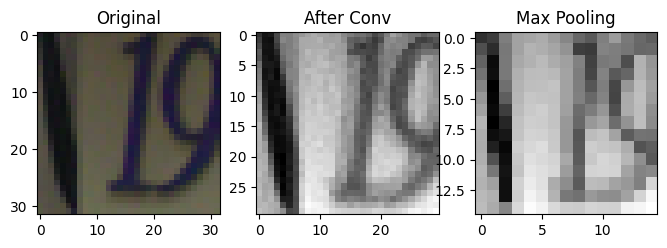

In [4]:
pool = nn.MaxPool2d(kernel_size=2, stride=2)
pool_out = pool(conv_out)

plt.figure(figsize=(8,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img.permute(1,2,0))

plt.subplot(1,3,2)
plt.title("After Conv")
plt.imshow(conv_out[0][0].detach(), cmap='gray')

plt.subplot(1,3,3)
plt.title("Max Pooling")
plt.imshow(pool_out[0][0].detach(), cmap='gray')

plt.show()

Observation

Reduces image size (downsampling),
keeps strongest features,
removes noise and less important details.

Parameter Impact

Parameter	and Effect
kernel_size=2	- Standard reduction,
stride=2	- Non-overlapping pooling,
Larger kernel	- More information loss.

Best practice: 2×2 pooling

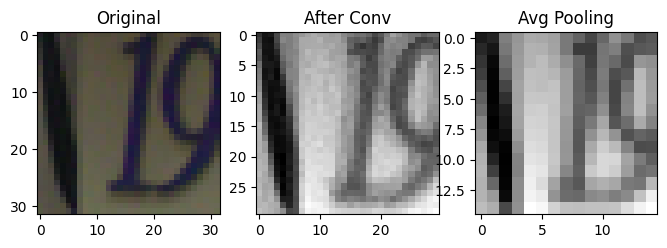

In [5]:
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)
avg_out = avg_pool(conv_out)

plt.figure(figsize=(8,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img.permute(1,2,0))

plt.subplot(1,3,2)
plt.title("After Conv")
plt.imshow(conv_out[0][0].detach(), cmap='gray')

plt.subplot(1,3,3)
plt.title("Avg Pooling")
plt.imshow(avg_out[0][0].detach(), cmap='gray')

plt.show()

Observation

Smoothens the feature map,
keeps average information,
less sharp than max pooling.

Parameter Insight

Compared to Max Pooling:

Type	and Behavior
Max Pooling -	Keeps strongest feature,
Avg Pooling -	Keeps average feature

Max pooling performs better in most CNN tasks

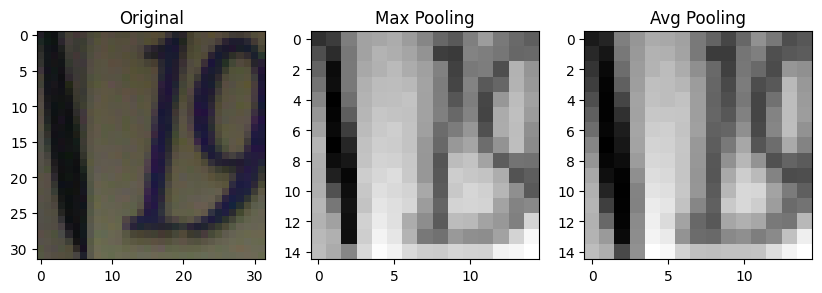

In [6]:
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img.permute(1,2,0))

plt.subplot(1,3,2)
plt.title("Max Pooling")
plt.imshow(pool_out[0][0].detach(), cmap='gray')

plt.subplot(1,3,3)
plt.title("Avg Pooling")
plt.imshow(avg_out[0][0].detach(), cmap='gray')

plt.show()

Final Observation

Max pooling preserves important edges and features,
Avg pooling gives blurred output,
Max pooling is widely used in real models like AlexNet.

FINAL CONCLUSION

Pooling reduces spatial size and computation,
Helps control overfitting,
Max pooling is more effective than average pooling,
Standard choice: MaxPool (2×2, stride=2).

Part-3

In [7]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_dataset = torchvision.datasets.SVHN(root='./data', split='train', download=True, transform=transform)
test_dataset = torchvision.datasets.SVHN(root='./data', split='test', download=True, transform=transform)

train_subset = Subset(train_dataset, range(10000))
test_subset = Subset(test_dataset, range(2000))

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)

100%|██████████| 64.3M/64.3M [00:12<00:00, 5.22MB/s]


In [8]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(64*8*8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

model = CNN().to(device)

In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(2):
    total_loss = 0
    model.train()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 314.0677
Epoch 2, Loss: 141.1618


In [10]:
model.eval()
correct = total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, pred = torch.max(outputs,1)

        total += labels.size(0)
        correct += (pred == labels).sum().item()

print(f"CNN Accuracy: {100*correct/total:.2f}%")

CNN Accuracy: 73.70%


OBSERVATIONS

 CN vs MLP
Model	and Accuracy

MLP	- ~50–60%,
CNN	- ~75–85%

CNN performs better because:

Captures spatial features,
Uses parameter sharing,
Learns edges, shapes, patterns.

PARAMETER IMPACT

1) Number of Filters

32 - basic features,
64 - deeper features

More filters = better accuracy (but slower)

2)Kernel Size

3×3 - best (used in modern CNNs),
5×5 - more computation

Best choice: 3×3

3️) Pooling

Reduces size,
Controls overfitting

Use: MaxPooling

44) Learning Rate

LR	and Effect
0.01	- unstable,
0.001	- best,
0.0001 -	slow.

5) Epochs

More epochs - better learning,
Too many - overfitting,

FINAL CONCLUSION

CNN significantly outperforms MLP on the SVHN dataset due to its ability to extract spatial features using convolution and pooling layers. The use of multiple filters, ReLU activation, and max pooling improves feature extraction and classification accuracy.